In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, PredefinedSplit
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve




In [ ]:
df_train = pd.read_csv("../outputs/processed_data/train_engineered.csv")
df_dev = pd.read_csv("../outputs/processed_data/dev_engineered.csv")
df_test = pd.read_csv("../outputs/processed_data/test_engineered.csv")

In [ ]:
x_train = df_train.drop(columns=["class"])
y_train = df_train["class"]
x_dev = df_dev.drop(columns=["class"])
y_dev = df_dev["class"]
x_test = df_test.drop(columns=["class"])
y_test = df_test["class"]

In [ ]:
X_train_dev = pd.concat([x_train, x_dev], axis=0).reset_index(drop=True)
y_train_dev = pd.concat([y_train, y_dev], axis=0).reset_index(drop=True)

test_fold = np.concatenate([
    #-1 for training, 0 for development
    np.full(len(x_train), -1),
    np.full(len(x_dev), 0)
])

reserved_split = PredefinedSplit(test_fold)

In [ ]:
# pipelines of svm with different imbalance handling techniques
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=7))
])

svm_class_balanced_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=7))
])

svm_smote_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=7)),
    ("svm", SVC(kernel="rbf", probability=True, random_state=7))
])

#hyperparameters for tuning
hyperparameters = {
    "svm__C": [0.01, 0.1, 1, 10, 100, 1000],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

In [ ]:
score = {"pr_auc": "average_precision", "roc_auc": "roc_auc", "f1": "f1", "recall": "recall", "precision": "precision"}

#find the best hyperparameters for each pipeline
svm_grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=hyperparameters,
    cv=reserved_split,
    scoring=score,
    n_jobs=-1,
    refit="pr_auc"
)
svm_grid_search.fit(X_train_dev, y_train_dev)

svm_class_balanced_grid_search = GridSearchCV(
    estimator=svm_class_balanced_pipeline,
    param_grid=hyperparameters,
    cv=reserved_split,
    scoring=score,
    n_jobs=-1,
    refit="pr_auc"
)
svm_class_balanced_grid_search.fit(X_train_dev, y_train_dev)

svm_smote_grid_search = GridSearchCV(
    estimator=svm_smote_pipeline,
    param_grid=hyperparameters,
    cv=reserved_split,
    scoring=score,
    n_jobs=-1,
    refit="pr_auc"
)
svm_smote_grid_search.fit(X_train_dev, y_train_dev)

,estimator,Pipeline(step...om_state=7))])
,param_grid,"{'svm__C': [0.01, 0.1, ...], 'svm__gamma': ['scale', 0.001, ...]}"
,scoring,"{'f1': 'f1', 'pr_auc': 'average_precision', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,-1
,refit,'pr_auc'
,cv,"PredefinedSpl...ape=(15213,)))"
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [ ]:
# get hyperparameters tuning results of svm, class balanced svm, smote svm
def get_tuning_results(model, model_name):
    results = pd.DataFrame(model.cv_results_)
    tuning_results = pd.DataFrame({
        "model": model_name,
        "dev_pr_auc_average_precision": results["mean_test_pr_auc"],
        "dev_roc_auc": results["mean_test_roc_auc"],
        "dev_f1_score": results["mean_test_f1"],
        "dev_recall": results["mean_test_recall"],
        "dev_precision": results["mean_test_precision"],
        "params": results["params"],
        "rank_dev_pr_auc": results["rank_test_pr_auc"]
    })

    tuning_results = tuning_results.sort_values("rank_dev_pr_auc").reset_index(drop=True)
    return tuning_results

svm_tuning_results = pd.concat([
    get_tuning_results(svm_grid_search, "SVM"),
    get_tuning_results(svm_class_balanced_grid_search, "Class Balanced SVM"),
    get_tuning_results(svm_smote_grid_search, "SMOTE SVM")
], ignore_index=True)

svm_tuning_results.to_csv("svm_tuning_results.csv", index=False)

svm_tuning_results

In [ ]:
def model_evaluation(model, model_name, X_test, y_test):
    best_estimator = model.best_estimator_
    y_proba = best_estimator.predict_proba(X_test)[:,1]

    #get prediction with threshold 0.5
    y_pred = (y_proba >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    results = {
        "model_name": model_name,
        "best_parameters": model.best_params_,
        "dev_average_precision": round(float(model.best_score_), 5),

        "test_accuracy": round(float(accuracy_score(y_test, y_pred)), 5),
        "test_precision_class_1": round(float(precision_score(y_test, y_pred, pos_label=1, zero_division=0)), 5),
        "test_recall_class_1": round(float(recall_score(y_test, y_pred, pos_label=1, zero_division=0)), 5),
        "test_f1_class_1": round(float(f1_score(y_test, y_pred, pos_label=1, zero_division=0)), 5),

        "test_roc_auc": round(float(roc_auc_score(y_test, y_proba)), 5),
        "test_pr_auc_average_precision": round(float(average_precision_score(y_test, y_proba)), 5),

        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    return results

svm_results = model_evaluation(svm_grid_search, "SVM", x_test, y_test)
svm_class_balanced_results = model_evaluation(svm_class_balanced_grid_search, "SVM_Class_balanced", x_test, y_test)
svm_smote_results = model_evaluation(svm_smote_grid_search, "SVM_SMOTE", x_test, y_test)

svm_final_results = pd.DataFrame([svm_results, svm_class_balanced_results, svm_smote_results])
svm_final_results.to_csv("../outputs/tables/svm_final_results.csv", index=False)

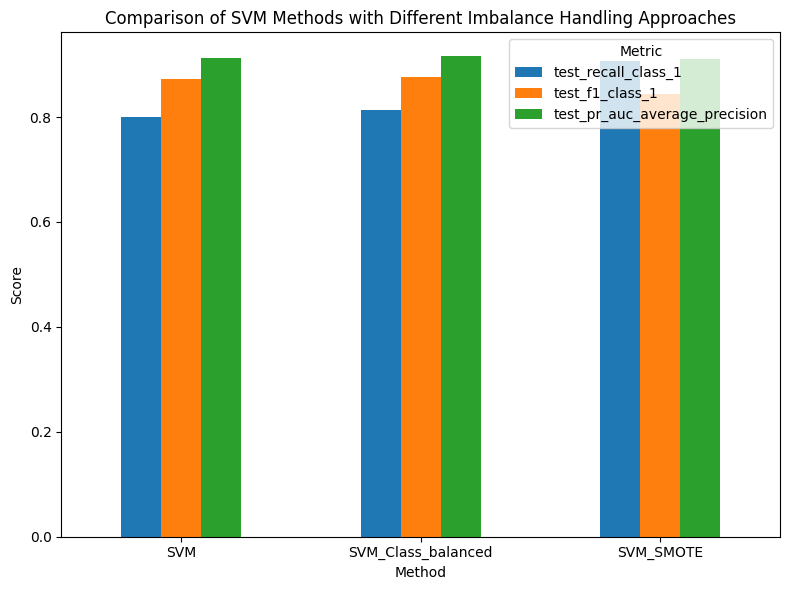

In [ ]:
# comparsion of different imbalance handling methods on svm
svm_final_results_copy = svm_final_results.copy()
plot_df = svm_final_results_copy[["model_name", "test_recall_class_1","test_f1_class_1","test_pr_auc_average_precision"]]
plot_df = plot_df.set_index("model_name")

ax = plot_df.plot(kind="bar", figsize=(8, 6))

plt.title("Comparison of SVM Methods with Different Imbalance Handling Approaches")
plt.xlabel("Method")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()



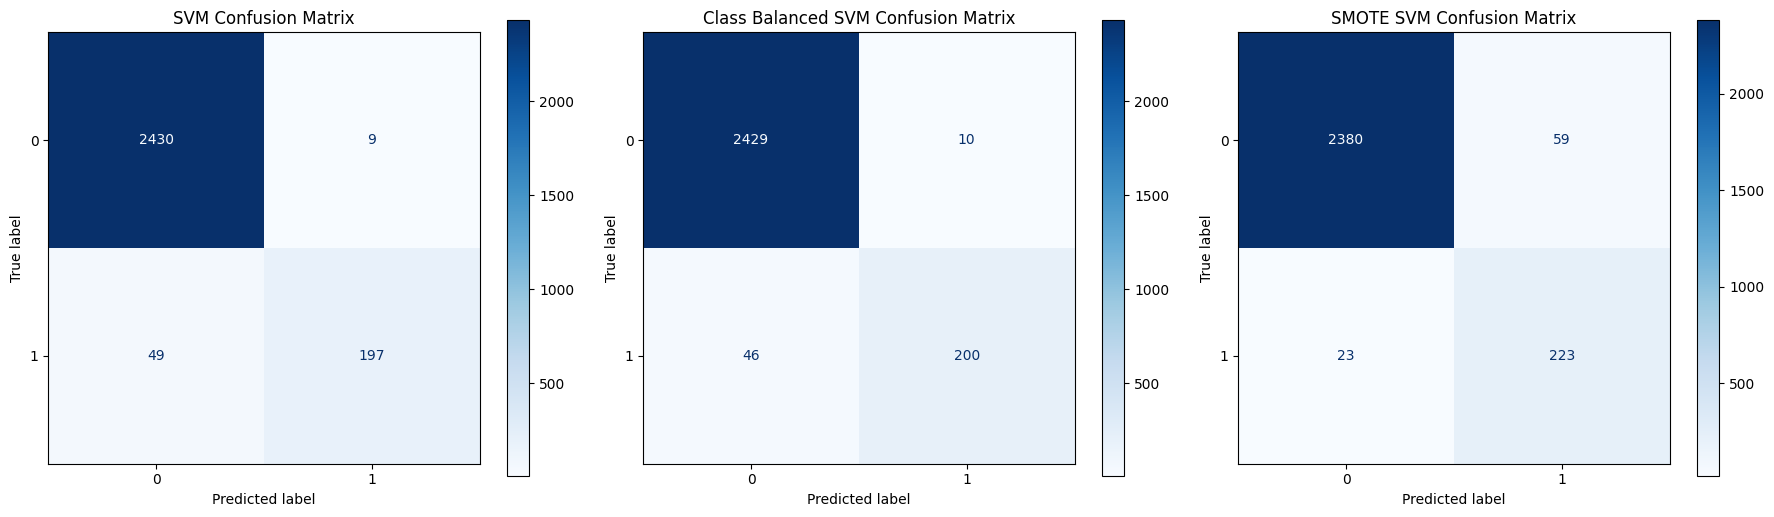

In [ ]:

y_score_svm = svm_grid_search.best_estimator_.predict_proba(x_test)[:,1]
y_predication_svm = (y_score_svm >= 0.5).astype(int)

y_score_class_balanced_svm = svm_class_balanced_grid_search.best_estimator_.predict_proba(x_test)[:,1]
y_predication_class_balanced_svm = (y_score_class_balanced_svm >= 0.5).astype(int)

y_score_smote_svm = svm_smote_grid_search.best_estimator_.predict_proba(x_test)[:,1]
y_predication_smote_svm = (y_score_smote_svm >= 0.5).astype(int) 

svm_confusion_matrix = confusion_matrix(y_test, y_predication_svm, labels=[0,1])
svm_class_balanced_confusion_matrix = confusion_matrix(y_test, y_predication_class_balanced_svm, labels=[0,1])
svm_smote_confusion_matrix = confusion_matrix(y_test, y_predication_smote_svm, labels=[0,1])

svm_cm_disp = ConfusionMatrixDisplay(confusion_matrix=svm_confusion_matrix, display_labels=[0,1])
svm_cb_cm_disp = ConfusionMatrixDisplay(confusion_matrix=svm_class_balanced_confusion_matrix, display_labels=[0,1])
svm_smote_cm_disp = ConfusionMatrixDisplay(confusion_matrix=svm_smote_confusion_matrix, display_labels=[0,1])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
svm_cm_disp.plot(ax=axes[0], cmap=plt.cm.Blues,colorbar=True)
svm_cb_cm_disp.plot(ax=axes[1], cmap=plt.cm.Blues, colorbar=True)
svm_smote_cm_disp.plot(ax=axes[2], cmap=plt.cm.Blues,colorbar=True)

axes[0].set_title("SVM Confusion Matrix")
axes[1].set_title("Class Balanced SVM Confusion Matrix")
axes[2].set_title("SMOTE SVM Confusion Matrix")

plt.tight_layout()
plt.show()

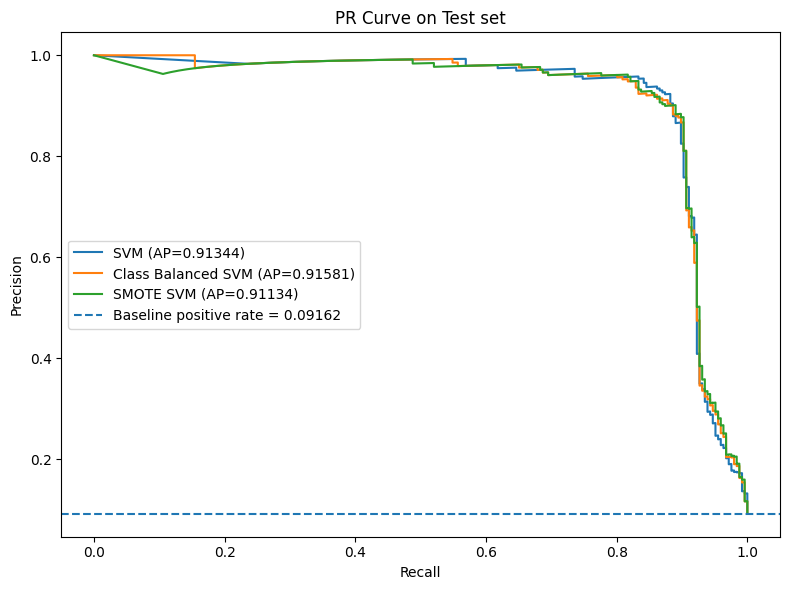

In [ ]:
plt.figure(figsize=(8, 6))

svm_precision, svm_recall, _ = precision_recall_curve(y_test, y_score_svm)
svm_average_precision = average_precision_score(y_test, y_score_svm)
plt.plot(svm_recall,svm_precision,label=f"SVM (AP={svm_average_precision:.5f})")

svm_cb_precision, svm_cb_recall, _ = precision_recall_curve(y_test,y_score_class_balanced_svm)
svm_cb_average_precision = average_precision_score(y_test,y_score_class_balanced_svm)
plt.plot(svm_cb_recall,svm_cb_precision,label=f"Class Balanced SVM (AP={svm_cb_average_precision:.5f})")

svm_smote_precision, svm_smote_recall, _ = precision_recall_curve(y_test,y_score_smote_svm)
svm_smote_average_precision = average_precision_score(y_test, y_score_smote_svm)

plt.plot(svm_smote_recall,svm_smote_precision,label=f"SMOTE SVM (AP={svm_smote_average_precision:.5f})")


baseline = y_test.mean()

plt.axhline(y=baseline,linestyle="--",label=f"Baseline positive rate = {positive_rate:.5f}")

plt.title("PR Curve on Test set")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

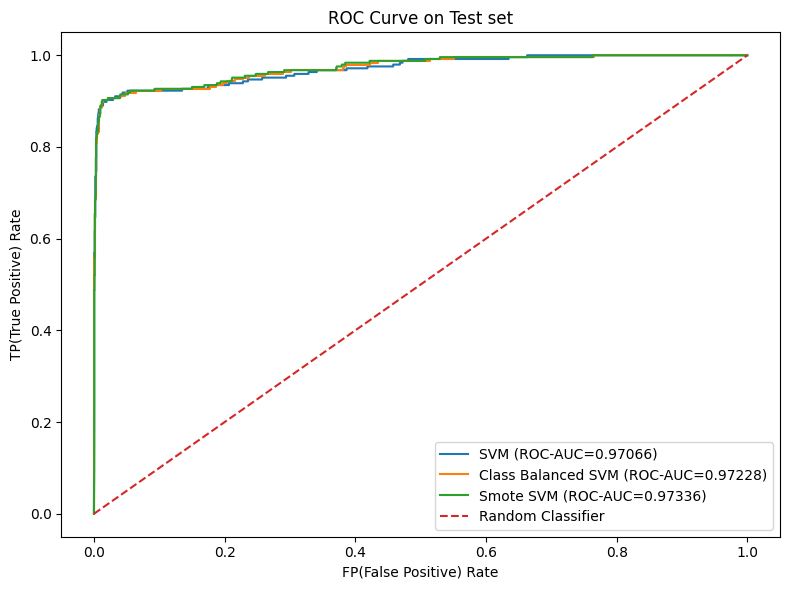

In [ ]:
plt.figure(figsize=(8, 6))

svm_fpr, svm_tpr, _ = roc_curve(y_test, y_score_svm)
svm_roc_auc = roc_auc_score(y_test, y_score_svm)
plt.plot(svm_fpr,svm_tpr,label=f"SVM (ROC-AUC={svm_roc_auc:.5f})")

svm_cb_fpr, svm_cb_tpr, _ = roc_curve(y_test, y_score_class_balanced_svm)
svm_cb_roc_auc = roc_auc_score(y_test, y_score_class_balanced_svm)
plt.plot(svm_cb_fpr,svm_cb_tpr,label=f"Class Balanced SVM (ROC-AUC={svm_cb_roc_auc:.5f})")

svm_smote_fpr, svm_smote_tpr, _ = roc_curve(y_test, y_score_smote_svm)
svm_smote_roc_auc = roc_auc_score(y_test, y_score_smote_svm)
plt.plot(svm_smote_fpr,svm_smote_tpr,label=f"Smote SVM (ROC-AUC={svm_smote_roc_auc:.5f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve on Test set")
plt.xlabel("FP(False Positive) Rate")
plt.ylabel("TP(True Positive) Rate")
plt.legend()
plt.tight_layout()
plt.show()